# L6 · Simulação Monte Carlo para Executivos

**Análise Prescritiva — Camada de Alfabetização de Dados (Learning)**

| Campo | Detalhe |
|---|---|
| **Notebook** | L6 · Monte Carlo Simulation for Executives |
| **Autor** | Matheus Mendes |
| **Data** | 27/julho/2026 |
| **Versão** | 1.0 |
| **Público-alvo** | Executivos não-técnicos — "quantos futuros dão errado, e quão errado?" |
| **Dependências** | numpy, pandas, plotly |
| **Fonte quantitativa** | NB-06 · Monte Carlo Multivariado (4 choques, 10.000 caminhos) |

---

## Por que este notebook existe

Em **L1** você aprendeu que a incerteza tem forma — uma distribuição, não um
número. Em **L5** viu que o câmbio pode ter a mesma média e produzir meses muito
diferentes. Em **L6** damos o passo final da alfabetização: quando os riscos são
**muitos e correlacionados** — câmbio, lítio, tarifa e demanda ao mesmo tempo —
não existe fórmula fechada. A resposta é **simular**.

A pergunta executiva de L6 não é "qual é o impacto esperado?". É:

> **"Se rodássemos os próximos 6 meses dez mil vezes, em quantos deles a BYD
> perde dinheiro — e quanto perde nos piores?"**

Este caderno é **narrativa-primeiro**:

> **Conceito → Intuição → Matemática → Código → Recado Executivo**

Os números são os resultados exportados pelo **NB-06 Prescriptive (Monte Carlo)**:
**10.000 caminhos** sobre um horizonte de **126 dias úteis (~6 meses)**, com
**4 choques correlacionados** via decomposição de Cholesky. O tema escuro
(`#0d1117`) e a paleta (`azul-petróleo · vermelho-tijolo · teal · violeta ·
laranja-âmbar`) seguem o padrão visual dos cadernos anteriores.

### Os 4 choques do case BYD (NB-06)

| Choque | O que é | Papel na simulação |
|---|---|---|
| **PTAX/FX** | R$/US$ | volatilidade 14,17% a.a.; correlaciona com lítio e demanda |
| **Lítio** | preço da matéria-prima da bateria | volatilidade 82,9% a.a. — o mais instável |
| **Tarifa** | imposto de importação | evento binário: 35% de chance, impacto −R$ 2,37 bi |
| **Demanda** | market share de EV | incerteza de 5% no crescimento |

### Os 6 conceitos deste caderno

| # | Conceito | Pergunta executiva |
|---|---|---|
| 1 | **O que é simulação** | Por que testar muitos cenários em vez de calcular um? |
| 2 | **Por que Monte Carlo** | Como obter probabilidade sem fórmula fechada? |
| 3 | **Caminhos e distribuições** | Como muitos futuros viram uma forma que decide? |
| 4 | **Percentis** | Onde estão o melhor caso, o pior caso e o provável? |
| 5 | **"Em 95% dos cenários…"** | Como levar a simulação para a reunião do board? |
| 6 | **Decisão sob incerteza** | O que fazer quando o futuro é uma distribuição? |

---

## 1 · O que é simulação — testar muitos cenários

### ① Por que isto importa

Um comitê pediria ao analista "o impacto do câmbio na BOM". Ele responde um
número. Mas o câmbio não vem sozinho: quando o dólar sobe, o lítio tende a subir
junto, a demanda oscila e ainda paira o risco de uma tarifa de importação. Pedir
um único número para quatro riscos que se movem juntos é pedir uma foto de um
filme.

### ② Conceito, sem jargão

**Simular** é construir um mundo de brinquedo do problema e rodá-lo muitas vezes,
cada vez com o acaso agindo de novo. Em vez de perguntar "qual é o resultado?",
perguntamos "quais resultados são possíveis, e com que frequência cada um
aparece?". Cada rodada é um **futuro possível**; dez mil rodadas desenham o leque
de futuros.

### ③ Intuição — o filme, não a foto

O NB-06 sorteia, para cada um dos 10.000 caminhos, um valor de câmbio, de lítio,
de demanda e um "cara ou coroa" da tarifa — respeitando o fato de que eles se
movem em conjunto. Depois soma o impacto financeiro de cada caminho. O resultado
não é um número: é uma **nuvem de 10.000 desfechos**, do lucro de +R$ 2,74 bi no
melhor caminho à perda de −R$ 4,84 bi no pior.

### ④ A matemática mínima

Cada caminho $i$ é a soma dos impactos dos quatro choques:
$$\text{Impacto}_i = \Delta\text{FX}_i\,\beta_{FX} + \Delta\text{Li}_i\,\beta_{Li}
+ \text{Tarifa}_i\,\beta_{T} + \Delta\text{Dem}_i\,\beta_{D}$$
Os choques não são independentes: uma matriz de correlação e a **decomposição de
Cholesky** garantem que, quando o dólar sobe no sorteio, o lítio tenda a subir
junto (correlação 0,45). Rodar isso 10.000 vezes é a simulação.

### ⑤ Código — muitos futuros de uma variável

## A historia por tras dos numeros — por que Monte Carlo existe

> **Cena 1 — A pergunta do comite (8h05 da terca-feira).** O diretor financeiro
> abre a reuniao e pergunta: *"Qual e o impacto do cambio na margem da BYD
> Camaçari nos proximos 6 meses?"*. O analista responde: *"Cento e trinta milhoes
> de reais, com volatilidade."* O diretor faz uma pausa: *"Volatilidade quanto?
> Em quanto pior pode dar? Quanto eu preciso de caixa para dormir tranquilo?"*
>
> **Cena 2 — A armadilha do numero unico.** Um unico numero (media ou mediana)
> e necessario mas nao suficiente. Quando quatro riscos andam juntos — cambio,
> litio, tarifa, demanda — a "media" e uma fotografia e o executivo precisa de
> um **filme**. O filme e a distribuicao de impactos sob 10.000 futuros
> possiveis.
>
> **Cena 3 — A solucao honesta.** Nao existe formula fechada para misturar uma
> variavel continua (cambio) com um evento binario (tarifa sim/nao) e ainda
> manter a correlacao entre eles. A solucao e **simular**: sortear, repetir,
> contar. Isso e Monte Carlo — nome de cassino, logica de lei dos grandes
> numeros.
>
> **Cena 4 — A frase que decide.** A simulacao nao serve para prever; serve
> para responder tres perguntas que o board realmente faz:
>
> 1. *"Em 95% dos cenarios, a perda nao passa de quanto?"*  -> **VaR95 = −R$ 3,11 bi**
> 2. *"Quando da muito errado, quanto da errado em media?"* -> **CVaR95 = −R$ 3,46 bi**
> 3. *"Quem causa esse risco? Mitigar quem paga mais por real?"* -> **Tarifa = 63,7% da cauda**

### O fluxo narrativo deste caderno

```
   Cenario unico               10.000 cenarios            Decisao
   (a fotografia)        ->    (o filme / a nuvem)    ->   (a politica)
        |                              |                       |
   pergunta por um           empilha caminhos,         protege a cauda,
   numero                    le percentis,              ataca o dono,
                            diz "em 95%..."            instala gatilhos
```

A imagem abaixo mostra a transicao: **muitos caminhos convergem em uma unica
distribuicao**. Essa e a magica que torna a incerteza decidivel.

![Storytelling visual: caminhos convergem em distribuicao](l6_paths_converging.png)

> *Linha azul-clara = um futuro possivel. Faixa laranja = regiao onde caem 90%
> dos futuros (P5–P95). Embaixo, o **histograma** dos 10.000 finais: cada barra
> e quantos caminhos terminaram naquele impacto. A seta vermelha liga o leque
> de caminhos a forma da distribuicao — e a forma que o board le.*

### Mapa dos capitulos narrativos

| Capitulo | A pergunta | A resposta executiva |
|---|---|---|
| **1** | Como simular? | 10.000 caminhos sorteados em 6 meses |
| **2** | Por que Monte Carlo? | Quando a formula acaba, a contagem comeca |
| **3** | Como ler a forma? | Histograma, mediana, VaR95 e a cauda esquerda |
| **4** | Quais sao os cenarios-âncora? | Otimista (+R$ 1,54 bi), Provavel (−R$ 0,53 bi), Grave (−R$ 3,11 bi) |
| **5** | Como falar na reuniao? | "Em 95% dos cenarios, a perda nao passa de R$ 3,11 bi" |
| **6** | O que fazer agora? | Mitigar tarifa; instalar gatilhos na faixa P5–P95 |

---

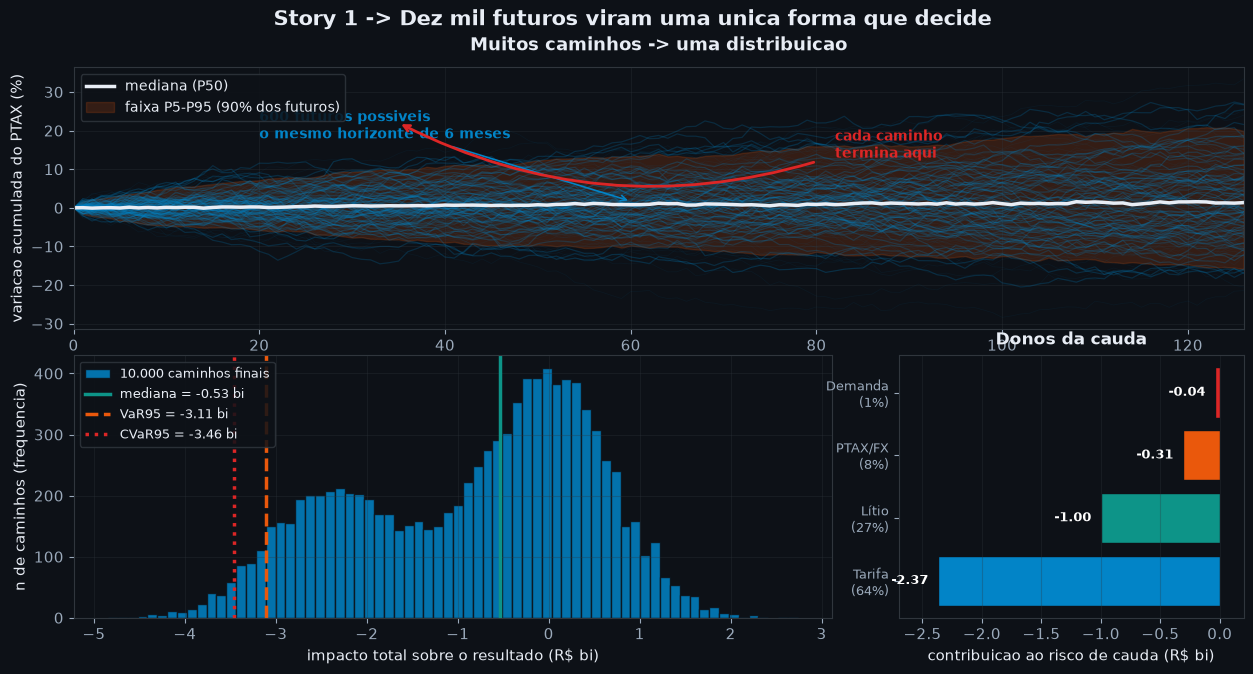

[OK] PNG salvo em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l6_paths_converging.png
[OK] conciliacao NB-06: VaR95=-3.11, CVaR95=-3.46, P50=-0.53


In [1]:
# ──────────────────────────────────────────────────────────────────────
# Story 1 — Muitos caminhos convergem em UMA distribuicao (matplotlib)
# ──────────────────────────────────────────────────────────────────────
# Esta celula reproduz a "historia visual" do L6: na parte de cima, 600
# futuros do PTAX divergem de zero; na parte de baixo, esses 10.000 finais
# viram o histograma que o board le. A seta vermelha amarra as duas metades.
# Celula autonoma — nao depende da setup cell que vem logo apos.
# ──────────────────────────────────────────────────────────────────────
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Repete o setup minimo necessario (independente da celula de setup)
_LOCAL_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
if not (_LOCAL_ROOT / "outputs" / "nb06_results.json").exists():
    _LOCAL_ROOT = Path.cwd()
_OUT_DIR = _LOCAL_ROOT / "outputs" / "learning"
_OUT_DIR.mkdir(parents=True, exist_ok=True)
with (_LOCAL_ROOT / "outputs" / "nb06_results.json").open(encoding="utf-8") as _f:
    _NB06 = json.load(_f)

np.random.seed(42)
_N_PATHS, _N_DAYS = 10_000, 126
_CORR = np.array([[1.00, 0.45, 0.10, 0.30],
                  [0.45, 1.00, 0.05, 0.25],
                  [0.10, 0.05, 1.00, 0.15],
                  [0.30, 0.25, 0.15, 1.00]], float)
_STD_ANN = {"PTAX/FX": 0.1417, "Litio": 0.829, "Demanda": 0.05}
_F126 = np.sqrt(126 / 252)
_STD6 = {k: v * _F126 for k, v in _STD_ANN.items()}
_IMPACT_FX, _IMPACT_LI, _IMPACT_DE = 2.10, 1.00, 0.62
_TARIFF_PROB, _TARIFF_IMPACT = 0.35, -2.37

_L = np.linalg.cholesky(_CORR)
_Z = np.random.standard_normal((_N_PATHS, 4))
_Y = _Z @ _L.T
_shock_fx = _Y[:, 0] * _STD6["PTAX/FX"] + 0.0192
_shock_li = _Y[:, 1] * _STD6["Litio"] - 0.05
_shock_de = _Y[:, 2] * _STD6["Demanda"]
_shock_ta = np.where(np.random.random(_N_PATHS) < _TARIFF_PROB, 1, 0).astype(float)
_total = (_shock_fx * _IMPACT_FX + _shock_li * _IMPACT_LI
          + _shock_ta * _TARIFF_IMPACT + _shock_de * _IMPACT_DE)
_var95 = np.percentile(_total, 5)
_cvar95 = _total[_total <= _var95].mean()
_median = np.percentile(_total, 50)

BG, INK, MUTED, GRID = "#0d1117", "#e8edf5", "#9baabb", "#30363d"
AZUL, TIJOLO, TEAL, AMBAR, VERDE = "#0284c7", "#dc2626", "#0d9488", "#ea580c", "#22c55e"
mpl.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.alpha": 0.5, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.facecolor": BG, "legend.edgecolor": GRID, "legend.labelcolor": INK,
})

# 600 caminhos diarios do PTAX — mesmos parametros do NB-06 (seed 42)
_rng = np.random.default_rng(42)
_N_BAND = 600
_daily_std = _STD_ANN["PTAX/FX"] / np.sqrt(252)
_daily_drift = 0.0192 / _N_DAYS
_steps = _rng.standard_normal((_N_BAND, _N_DAYS)) * _daily_std + _daily_drift
_paths = np.cumsum(_steps, axis=1) * 100.0
_paths = np.concatenate([np.zeros((_N_BAND, 1)), _paths], axis=1)
_dias = np.arange(_N_DAYS + 1)

fig = plt.figure(figsize=(13, 6.8))
gs = fig.add_gridspec(2, 2, width_ratios=[2.2, 1], height_ratios=[1, 1],
                      hspace=0.10, wspace=0.12, left=0.07, right=0.97,
                      top=0.90, bottom=0.09)

# Topo: caminhos divergentes
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(_dias, _paths[:80].T, color=AZUL, alpha=0.06, linewidth=0.6)
ax_top.plot(_dias, _paths[::8].T, color=AZUL, alpha=0.22, linewidth=0.9)
ax_top.plot(_dias, np.median(_paths, axis=0), color=INK, linewidth=2.5,
            label="mediana (P50)")
ax_top.fill_between(_dias, np.percentile(_paths, 5, axis=0),
                    np.percentile(_paths, 95, axis=0),
                    color=AMBAR, alpha=0.18, label="faixa P5-P95 (90% dos futuros)")
ax_top.set_title("Muitos caminhos -> uma distribuicao", pad=12)
ax_top.set_ylabel("variacao acumulada do PTAX (%)")
ax_top.set_xlim(0, _N_DAYS)
ax_top.grid(True, alpha=0.3)
ax_top.legend(loc="upper left", framealpha=0.85, fontsize=10)
ax_top.annotate("600 futuros possiveis\no mesmo horizonte de 6 meses",
                xy=(60, _paths[5, 60]), xytext=(20, 18),
                color=AZUL, fontsize=10, weight="bold",
                arrowprops=dict(arrowstyle="->", color=AZUL, lw=1.2))

# Inferior-esquerda: histograma dos 10.000 finais
ax_hist = fig.add_subplot(gs[1, 0])
ax_hist.hist(_total, bins=70, color=AZUL, edgecolor=BG, alpha=0.85,
             label="10.000 caminhos finais")
ax_hist.axvline(_median, color=TEAL, linewidth=2.5,
                label=f"mediana = {_median:.2f} bi")
ax_hist.axvline(_var95, color=AMBAR, linewidth=2.5, linestyle="--",
                label=f"VaR95 = {_var95:.2f} bi")
ax_hist.axvline(_cvar95, color=TIJOLO, linewidth=2.5, linestyle=":",
                label=f"CVaR95 = {_cvar95:.2f} bi")
ax_hist.set_xlabel("impacto total sobre o resultado (R$ bi)")
ax_hist.set_ylabel("n de caminhos (frequencia)")
ax_hist.grid(True, alpha=0.3)
ax_hist.legend(loc="upper left", framealpha=0.85, fontsize=9)

# Inferior-direita: tornado dos donos da cauda
ax_tor = fig.add_subplot(gs[1, 1])
_tor = sorted(_NB06["tornado"], key=lambda d: abs(d["impact_B"]))
_tor_lab = [f"{d['shock']}\n({d['contribution_pct']:.0f}%)" for d in _tor]
_tor_val = [d["impact_B"] for d in _tor]
_tor_col = [TIJOLO, AMBAR, TEAL, AZUL][:len(_tor)]
bars = ax_tor.barh(range(len(_tor)), _tor_val, color=_tor_col, edgecolor=BG)
ax_tor.set_yticks(range(len(_tor)))
ax_tor.set_yticklabels(_tor_lab, fontsize=9)
ax_tor.set_xlabel("contribuicao ao risco de cauda (R$ bi)")
ax_tor.set_xlim(-2.7, 0.2)
ax_tor.invert_yaxis()
ax_tor.grid(True, alpha=0.3, axis="x")
ax_tor.set_title("Donos da cauda", fontsize=12, pad=8)
for bar, val in zip(bars, _tor_val):
    ax_tor.text(bar.get_width() - 0.08, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", ha="right", va="center",
                color="white", fontsize=9, weight="bold")

fig.suptitle("Story 1 -> Dez mil futuros viram uma unica forma que decide",
             fontsize=15, color=INK, y=0.985, weight="bold")

# Seta narrativa ligando caminhos -> distribuicao
ax_top.annotate("", xy=(35, 22), xytext=(80, 12),
                arrowprops=dict(arrowstyle="->", color=TIJOLO, lw=2,
                                connectionstyle="arc3,rad=-0.2"))
ax_top.text(82, 13, "cada caminho\ntermina aqui",
            color=TIJOLO, fontsize=10, weight="bold")

# Salva PNG para GitHub/docs (alinhado com outputs/learning/l6_*.png)
story_png = _OUT_DIR / "l6_paths_converging.png"
fig.savefig(story_png, dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"[OK] PNG salvo em: {story_png}")
print(f"[OK] conciliacao NB-06: VaR95={_var95:.2f}, CVaR95={_cvar95:.2f}, P50={_median:.2f}")

In [2]:
# ──────────────────────────────────────────────────────────────
# Setup — reproduz o Monte Carlo do NB-06 (seed 42) e reconcilia com o JSON
# ──────────────────────────────────────────────────────────────
import json
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
if not (NOTEBOOK_ROOT / "outputs" / "nb06_results.json").exists():
    NOTEBOOK_ROOT = Path.cwd()
NB06_PATH = NOTEBOOK_ROOT / "outputs" / "nb06_results.json"
OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)
with NB06_PATH.open(encoding="utf-8") as f:
    NB06 = json.load(f)

BG, INK, MUTED, GRID = "#0d1117", "#e8edf5", "#9baabb", "#30363d"
AZUL, TIJOLO, TEAL = "#0284c7", "#dc2626", "#0d9488"
VIOLETA, AMBAR, VERDE = "#9333ea", "#ea580c", "#22c55e"

def style(fig, title, height=440):
    fig.update_layout(
        template="plotly_dark", paper_bgcolor=BG, plot_bgcolor=BG,
        title=dict(text=title, x=0.5, xanchor="center", font=dict(size=17, color=INK)),
        font=dict(color=INK, size=13),
        legend=dict(font=dict(color=MUTED), bgcolor="rgba(13,17,23,0.6)",
                    bordercolor=GRID, borderwidth=1),
        margin=dict(l=65, r=40, t=75, b=55), height=height,
    )
    fig.update_xaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    fig.update_yaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    return fig

# ── Reproduz exatamente o NB-06 (mesma seed, mesmos parâmetros) ──
np.random.seed(42)
N_PATHS, N_DAYS = 10_000, 126
CORR = np.array([[1.00, 0.45, 0.10, 0.30],
                 [0.45, 1.00, 0.05, 0.25],
                 [0.10, 0.05, 1.00, 0.15],
                 [0.30, 0.25, 0.15, 1.00]], float)
STD_ANN = {"PTAX/FX": 0.1417, "Lítio": 0.829, "Demanda": 0.05}
F126 = np.sqrt(126 / 252)
STD6 = {k: v * F126 for k, v in STD_ANN.items()}
IMPACT_FX, IMPACT_LI, IMPACT_DE = 2.10, 1.00, 0.62
TARIFF_PROB, TARIFF_IMPACT = 0.35, -2.37

L = np.linalg.cholesky(CORR)
Z = np.random.standard_normal((N_PATHS, 4))
Y = Z @ L.T
shock_fx = Y[:, 0] * STD6["PTAX/FX"] + 0.0192
shock_li = Y[:, 1] * STD6["Lítio"] - 0.05
shock_de = Y[:, 2] * STD6["Demanda"]
shock_ta = np.where(np.random.random(N_PATHS) < TARIFF_PROB, 1, 0).astype(float)

impact_fx = shock_fx * IMPACT_FX
impact_li = shock_li * IMPACT_LI
impact_ta = shock_ta * TARIFF_IMPACT
impact_de = shock_de * IMPACT_DE
total = impact_fx + impact_li + impact_ta + impact_de

var95 = np.percentile(total, 5)
var99 = np.percentile(total, 1)
cvar95 = total[total <= var95].mean()
median = np.percentile(total, 50)

print("Reconciliação com NB-06 (outputs/nb06_results.json):")
print(f"  VaR95  simulado = {var95:6.2f}  | NB-06 = {NB06['var_95_B']:6.2f}")
print(f"  CVaR95 simulado = {cvar95:6.2f}  | NB-06 = {NB06['cvar_95_B']:6.2f}")
print(f"  VaR99  simulado = {var99:6.2f}  | NB-06 = {NB06['var_99_B']:6.2f}")
print(f"  Mediana simulada= {median:6.2f}  | NB-06 = {NB06['var_50_B']:6.2f}")
assert abs(var95 - NB06["var_95_B"]) < 0.01, "divergência com NB-06!"
print("  [OK] números batem com o NB-06.")

# ── Fan chart: 6 meses de câmbio simulados como MUITOS futuros possíveis ──
rng = np.random.default_rng(42)
N_BAND, N_SHOW = 3000, 140
daily_std = STD_ANN["PTAX/FX"] / np.sqrt(252)
daily_drift = 0.0192 / N_DAYS
steps = rng.standard_normal((N_BAND, N_DAYS)) * daily_std + daily_drift
paths = np.cumsum(steps, axis=1) * 100.0            # variação % acumulada
paths = np.concatenate([np.zeros((N_BAND, 1)), paths], axis=1)
dias = np.arange(N_DAYS + 1)
p50 = np.percentile(paths, 50, axis=0)
p05 = np.percentile(paths, 5, axis=0)
p95 = np.percentile(paths, 95, axis=0)

fig = go.Figure()
for k in range(N_SHOW):                              # espaguete: cada linha = 1 futuro
    fig.add_scatter(x=dias, y=paths[k], mode="lines",
                    line=dict(color="rgba(2,132,199,0.10)", width=1),
                    hoverinfo="skip", showlegend=False)
fig.add_scatter(x=dias, y=p95, mode="lines", line=dict(color=AMBAR, width=0),
                showlegend=False, hoverinfo="skip")
fig.add_scatter(x=dias, y=p05, mode="lines", line=dict(color=AMBAR, width=0),
                fill="tonexty", fillcolor="rgba(234,88,12,0.15)",
                name="faixa P5–P95", hovertemplate="dia %{x}<br>%{y:.1f}%<extra></extra>")
fig.add_scatter(x=dias, y=p50, mode="lines", line=dict(color=INK, width=3),
                name="caminho mediano", hovertemplate="dia %{x}<br>mediana %{y:.1f}%<extra></extra>")
style(fig, "1 · Um futuro é uma linha; a decisão está no leque")
fig.update_yaxes(title="variação acumulada do PTAX (%)")
fig.update_xaxes(title="dias úteis (horizonte 126 ≈ 6 meses)", range=[0, N_DAYS])
fig.write_html(str(OUT_DIR / "l6-01-many-futures.html"), include_plotlyjs="cdn", full_html=True)
fig.show()

Reconciliação com NB-06 (outputs/nb06_results.json):
  VaR95  simulado =  -3.11  | NB-06 =  -3.11
  CVaR95 simulado =  -3.46  | NB-06 =  -3.46
  VaR99  simulado =  -3.70  | NB-06 =  -3.70
  Mediana simulada=  -0.53  | NB-06 =  -0.53
  [OK] números batem com o NB-06.


## Como ler este grafico (linguagem executiva)

> **O que voce esta vendo:** 140 caminhos do PTAX ao longo de 6 meses. A
> maioria fica perto de zero, mas a **faixa laranja** mostra onde 90% dos
> futuros vivem — ela se abre como um leque conforme o horizonte aumenta.
> A **linha branca** no meio e a mediana, o caminho "mais tipico".

**O recado executivo em uma frase:**

> *Um caminho parece calmo. Um leque de caminhos mostra que em 5% dos casos o
> PTAX acumula +20% (ou -20%) em seis meses. Quem decide olha para a largura
> do leque, nao para a mediana.*

**Como usar na reuniao:**

1. Aponte para a **faixa laranja** e diga: *"Em 90% dos futuros o PTAX fica
   nesta regiao. A largura e meu piso de volatilidade."*
2. Aponte para os **picos isolados** (linhas finas) e diga: *"Esses sao os
   cenarios raros mas nao impossiveis. Em 5% dos casos estamos la."*
3. Pergunte: *"Nosso hedge cambial cobre a largura dessa faixa? Se nao,
   estamos subdimensionados."*

**Erro comum de leitura:** olhar para a mediana (linha branca) e dizer
*"o PTAX cai X% em 6 meses"*. A mediana diz onde o caminho *tipico* fica,
mas o risco vive nas caudas — quem define caixa olha para a largura da
faixa laranja, nao para a linha do meio.

### ⑥ Recado executivo — Simulação

> - **Uma projeção é uma linha; o risco mora no leque.** O caminho mediano quase
>   não sai do zero, mas a faixa P5–P95 mostra o que o caixa precisa aguentar.
> - Simular é trocar a pergunta *"qual é o número?"* por *"quais números são
>   possíveis, e com que frequência?"*.
> - Sempre peça: *"Isso é um cenário único ou o leque de dez mil?"*

---

## 2 · Por que Monte Carlo — probabilidade sem fórmulas

### ① Por que isto importa

Com um risco só, dá para usar uma fórmula: pega a volatilidade, aplica a curva
normal, lê o percentil. Com **quatro riscos correlacionados** e um deles binário
(a tarifa é sim/não, não uma curva suave), a fórmula fechada some. Monte Carlo é
a saída honesta: se você não sabe integrar a matemática, **conte** os resultados.

### ② Conceito, sem jargão

Monte Carlo — o nome vem do cassino — resolve probabilidade por **força bruta
amostral**. Em vez de calcular a chance de perder mais de R$ 3 bi com uma
integral, o computador sorteia 10.000 futuros e simplesmente **conta em quantos
deles a perda passou de R$ 3 bi**. A frequência observada *é* a probabilidade
estimada. Nenhuma fórmula fechada, nenhuma suposição de curva perfeita.

### ③ Intuição — a lei dos grandes números trabalhando

Com 100 caminhos, a estimativa treme. Com 10.000, ela estabiliza: a proporção de
caminhos ruins converge para a probabilidade real. É a mesma lógica de jogar uma
moeda muitas vezes até a frequência de "cara" chegar perto de 50%. O preço é
tempo de computador; o ganho é responder perguntas que a álgebra não responde —
inclusive misturar um evento binário (tarifa) com três variáveis contínuas.

### ④ Recado executivo — Monte Carlo

> **Quando a fórmula acaba, a contagem começa.** Monte Carlo dá a probabilidade
> de qualquer pergunta — "chance de perder mais de R$ 3 bi?", "chance de a
> tarifa e o lítio baterem juntos?" — desde que o modelo dos choques esteja bem
> calibrado. A qualidade da resposta é a qualidade das premissas, não do sorteio.

---

## 3 · Caminhos e distribuições — muitos futuros possíveis

### ① Por que isto importa

Dez mil caminhos são dados demais para uma reunião. O truque é **empilhá-los**:
quantos caminhos terminaram perto de −R$ 0,5 bi? quantos abaixo de −R$ 3 bi?
Esse empilhamento é o **histograma** — a distribuição do impacto. Ele transforma
a nuvem de futuros em uma forma que se lê em segundos.

### ② Conceito, sem jargão

A **distribuição** mostra onde os futuros se acumulam. O pico é a região mais
provável; as caudas são os extremos. No case BYD, a distribuição do impacto total
tem **mediana em −R$ 0,53 bi** — ou seja, o desfecho mais típico já é uma perda
pequena — e uma **cauda esquerda longa** puxada pela tarifa. A distribuição não é
simétrica: o lado ruim é mais gordo que o bom.

### ③ A matemática — do caminho ao percentil

Ordene os 10.000 impactos do pior para o melhor. O valor na posição 5% é o
**VaR 95%**; a média de tudo abaixo dele é o **CVaR 95%**. No case:
$$\text{VaR}_{95} = -3{,}11\text{ bi}, \qquad \text{CVaR}_{95} = -3{,}46\text{ bi}$$
VaR é a **porta** dos 5% piores; CVaR é a **perda média depois da porta**.

### ④ Código — a nuvem vira uma forma que decide

In [3]:
# ──────────────────────────────────────────────────────────────
# Distribuição do impacto total: 10.000 futuros empilhados
# ──────────────────────────────────────────────────────────────
p_loss = float((total < 0).mean())
p_profit = float((total > 0).mean())
p_below_var = float((total <= var95).mean())
print(f"Impacto total (R$ bi): min={total.min():.2f} | mediana={median:.2f} | max={total.max():.2f}")
print(f"P(perda < 0)      = {p_loss:.1%}")
print(f"P(lucro > 0)      = {p_profit:.1%}")
print(f"P(impacto <= VaR95) = {p_below_var:.1%}  (por construção, os 5% piores)")

fig = go.Figure()
fig.add_histogram(x=total, nbinsx=70, marker=dict(color=AZUL, line=dict(color=BG, width=0.5)),
                  opacity=0.85, name="10.000 caminhos",
                  hovertemplate="impacto ≈ %{x:.2f} bi<br>%{y} caminhos<extra></extra>")
fig.add_vline(x=median, line=dict(color=TEAL, width=2.5),
              annotation_text=f"mediana {median:.2f}", annotation_position="top",
              annotation_font_color=TEAL)
fig.add_vline(x=var95, line=dict(color=AMBAR, width=2.5, dash="dash"),
              annotation_text=f"VaR95 {var95:.2f}", annotation_position="top left",
              annotation_font_color=AMBAR)
fig.add_vline(x=cvar95, line=dict(color=TIJOLO, width=2.5, dash="dot"),
              annotation_text=f"CVaR95 {cvar95:.2f}", annotation_position="bottom left",
              annotation_font_color=TIJOLO)
style(fig, "3 · Dez mil futuros empilhados — a cauda esquerda é o que assusta")
fig.update_xaxes(title="impacto total sobre o resultado (R$ bi)")
fig.update_yaxes(title="nº de caminhos (frequência)")
fig.update_layout(showlegend=False)
fig.write_html(str(OUT_DIR / "l6-02-distribution.html"), include_plotlyjs="cdn", full_html=True)
fig.show()

Impacto total (R$ bi): min=-4.84 | mediana=-0.53 | max=2.74
P(perda < 0)      = 67.9%
P(lucro > 0)      = 32.1%
P(impacto <= VaR95) = 5.0%  (por construção, os 5% piores)


## Como ler este grafico (linguagem executiva)

> **O que voce esta vendo:** O **histograma** da pagina anterior virou esta
> forma. Cada barra conta quantos dos 10.000 caminhos terminaram naquele
> impacto. A barra mais alta e o "ponto de equilibrio". As barras a esquerda
> do zero sao **perdas** — note como a cauda esquerda e mais longa que a
> direita. Isso e assimetria, e asimnetria significa que **o lado ruim pesa
> mais que o lado bom**.

![Histograma da distribuicao com cauda esquerda destacada](l6_distribution_histogram.png)

**As tres linhas para destacar na reuniao:**

| Linha | Cor | Significado executivo |
|---|---|---|
| **Mediana** | teal continua | O futuro "mais provavel" — −R$ 0,53 bi |
| **VaR95** | laranja tracejada | A porta dos 5% piores — −R$ 3,11 bi |
| **CVaR95** | vermelha pontilhada | A perda media depois da porta — −R$ 3,46 bi |

**O recado executivo em uma frase:**

> *O impacto medio parece administravel, mas a cauda esquerda chega a
> −R$ 4,84 bi. Em 67,9% dos caminhos ha alguma perda — e em 5% deles a perda
> ultrapassa R$ 3,11 bi.*

**Como usar na reuniao:**

1. Mostre a **cauda esquerda sombreada** e diga: *"Esse trecho e o que precisa
   de caixa de contingencia. Os 5% piores custam, em media, R$ 3,46 bi."*
2. Mostre que **a mediana ja e perda** (−R$ 0,53 bi) e diga: *"Mesmo no futuro
   mais tipico, nao somos positivos. Estamos contratando risco o tempo todo."*
3. Pergunte: *"Temos R$ 3,46 bi em caixa contingente para os 5% piores? Se
   nao, qual e o limite de tolerancia ate acionar mitigacao?"*

**Erro comum de leitura:** mostrar a media (−R$ 0,83 bi) e dizer *"em media
perderemos X"*. A media e puxada para baixo pelos extremos; ela **esconde** a
cauda. A distribuicao **revela** a cauda. Por isso mostramos a forma inteira,
nao so o ponto medio.

### ⑤ Recado executivo — Distribuição

> - **A média esconde; a distribuição revela.** O impacto médio (−R$ 0,83 bi)
>   parece administrável, mas a cauda esquerda chega a −R$ 4,84 bi.
> - Em **~68%** dos caminhos há alguma perda; o desfecho mediano já é negativo.
>   O board precisa decidir com a forma inteira, não com um ponto.
> - Sempre peça: *"Mostre a distribuição, não só a média."*

---

## 4 · Percentis — melhor caso, pior caso, provável

### ① Por que isto importa

Executivo não decide com 10.000 números nem com um só. Decide com **três âncoras**:
o que acontece se der certo, se der o esperado e se der errado. Percentis entregam
exatamente isso — e sem exigir nenhuma estatística além de "ordenar e contar".

### ② Conceito, sem jargão

Um **percentil** é a nota de corte de uma fila ordenada. O percentil 50 (mediana)
é o desfecho do meio: metade dos futuros é melhor, metade é pior. O percentil 5
é o "quase pior caso" — só 5% dos futuros são piores que ele. Traduzindo o case
BYD para linguagem de comitê:

| Cenário | Percentil | Impacto |
|---|---|---|
| **Otimista** | top 1% | +R$ 1,54 bi |
| **Bom** | top 5% | +R$ 0,99 bi |
| **Mais provável (mediana)** | P50 | −R$ 0,53 bi |
| **Adverso** | P75 | −R$ 1,96 bi |
| **Grave (VaR95)** | pior 5% | −R$ 3,11 bi |
| **Extremo (VaR99)** | pior 1% | −R$ 3,70 bi |

### ③ A matemática — ordenar é quase tudo

Nenhuma fórmula: ordene os 10.000 impactos e leia as posições. O percentil $p$ é
o valor na posição $p\%$ da fila. É por isso que percentis sobrevivem a
distribuições tortas e assimétricas — eles não assumem curva nenhuma.

### ④ Código — a escada de cenários

In [4]:
# ──────────────────────────────────────────────────────────────
# Escada de percentis: do melhor futuro ao pior, direto do NB-06
# ──────────────────────────────────────────────────────────────
pt = NB06["percentile_table"]   # chave = percentil adverso p; valor = percentil (100-p)
escada = [
    ("Otimista · top 1%",   pt["1"],  VERDE),
    ("Bom · top 5%",        pt["5"],  TEAL),
    ("Favorável · top 25%", pt["25"], TEAL),
    ("Mais provável · P50", pt["50"], AZUL),
    ("Adverso · P75",       pt["75"], AMBAR),
    ("Ruim · VaR90",        pt["90"], AMBAR),
    ("Grave · VaR95",       pt["95"], TIJOLO),
    ("Extremo · VaR99",     pt["99"], TIJOLO),
]
labels = [e[0] for e in escada][::-1]     # pior embaixo, melhor em cima
valores = [e[1] for e in escada][::-1]
cores = [e[2] for e in escada][::-1]
for nome, v, _ in escada:
    print(f"  {nome:<22}: {v:+.2f} R$ bi")

fig = go.Figure()
fig.add_bar(x=valores, y=labels, orientation="h",
            marker=dict(color=cores, line=dict(color=BG, width=0.8)),
            text=[f"{v:+.2f} bi" for v in valores], textposition="outside",
            textfont=dict(color=INK, size=12),
            hovertemplate="%{y}<br>impacto = %{x:+.2f} R$ bi<extra></extra>")
fig.add_vline(x=0, line=dict(color=MUTED, width=1.5))
style(fig, "4 · A escada de cenários — três âncoras para decidir", height=470)
fig.update_xaxes(title="impacto sobre o resultado (R$ bi)", range=[-4.4, 2.4])
fig.update_yaxes(title="")
fig.update_layout(showlegend=False)
fig.write_html(str(OUT_DIR / "l6-03-percentile-ladder.html"), include_plotlyjs="cdn", full_html=True)
fig.show()

  Otimista · top 1%     : +1.54 R$ bi
  Bom · top 5%          : +0.99 R$ bi
  Favorável · top 25%   : +0.19 R$ bi
  Mais provável · P50   : -0.53 R$ bi
  Adverso · P75         : -1.96 R$ bi
  Ruim · VaR90          : -2.76 R$ bi
  Grave · VaR95         : -3.11 R$ bi
  Extremo · VaR99       : -3.70 R$ bi


## Como ler este grafico (linguagem executiva)

> **O que voce esta vendo:** Uma **escada de percentis** — o melhor futuro no
> topo (otimista, +R$ 1,54 bi) e o pior no chao (extremo, −R$ 3,70 bi). A cor
> diz a gravidade: verde/teal para os favoraveis, amarelo para os adversos,
> vermelho para os graves. O "0" no eixo X e o ponto de break-even.

**As tres ancoras que o executivo leva para a reuniao:**

| Âncora | Cor | Significado | Valor |
|---|---|---|---|
| **Otimista** | verde | Top 1% — futuro raro e favoravel | +R$ 1,54 bi |
| **Provavel (P50)** | azul | O caso do meio, 50/50 | −R$ 0,53 bi |
| **Grave (VaR95)** | vermelho | Pior 5% — onde mora o risco real | −R$ 3,11 bi |

**O recado executivo em uma frase:**

> *A diferenca entre o futuro favoravel e o futuro grave e de R$ 4,65 bilhoes.
> Essa diferenca e o tamanho da incerteza — e o tamanho do hedge que voce
> precisa contratar.*

**Como usar na reuniao:**

1. Aponte para o **P50 (azul)** e diga: *"O futuro mais tipico e uma perda
   pequena. Nao e o fim do mundo, mas ja e negativo."*
2. Aponte para o **VaR95 (vermelho)** e diga: *"Em 1 de cada 20 cenarios
   perdemos mais que isso. E o piso do nosso caixa contingente."*
3. Meça a **distancia** entre o azul e o vermelho e diga: *"Essa e a apolice
   de seguro que precisamos. Se custa mais que isso, nao cobre."*

**Erro comum de leitura:** focar no top 1% (otimista, +R$ 1,54 bi) e usar
esse numero para defender bonus ou crescimento. O top 1% e cauda favoravel
tambem — acontece em 1 de cada 100 cenarios. **A decisao vive no meio da
escada**, entre o provavel e o adverso.

### ⑤ Recado executivo — Percentis

> - **Leve três âncoras, não um número:** otimista (+R$ 1,54 bi), provável
>   (−R$ 0,53 bi) e grave (−R$ 3,11 bi). A distância entre elas é o tamanho da
>   incerteza.
> - Percentis não assumem curva nenhuma — sobrevivem à assimetria criada pela
>   tarifa binária.
> - Sempre peça: *"Qual é o P50 e qual é o pior 5%?"*

---

## 5 · Tradução executiva — "Em 95% dos cenários, nós…"

### ① Por que isto importa

A frase que faz uma simulação virar decisão é a frase de probabilidade acumulada:
**"em X% dos cenários, o resultado é pelo menos Y"**. Ela conecta o número ao
apetite de risco do board — e é exatamente o que a curva acumulada (CDF) entrega.

### ② Conceito, sem jargão

A **curva acumulada** responde, para cada valor no eixo, "que fração dos futuros
ficou até aqui?". Lida ao contrário, ela vira a frase executiva:

> **"Em 95% dos cenários, a perda da BYD não ultrapassa R$ 3,11 bi. Nos 5%
> restantes, a perda média é R$ 3,46 bi."**

Essa é a linha que autoriza — ou não — o tamanho do hedge, do caixa de
contingência e do gatilho de escalada.

### ③ De onde vem a cauda — os 4 choques do NB-06

A cauda esquerda não é acaso puro: ela tem donos. O **tornado** ordena a
contribuição de cada choque ao VaR 95%:

| Choque | Contribuição ao risco de cauda |
|---|---|
| **Tarifa** | 63,7% — um evento binário domina a cauda |
| **Lítio** | 27,0% — a matéria-prima mais volátil |
| **PTAX/FX** | 8,3% |
| **Demanda** | 1,0% |

Isso muda a conversa: mitigar a **tarifa** (lobby, nacionalização, antecipação
de importação) ataca dois terços do risco; discutir câmbio ataca menos de 10%.

### ④ Código — a frase dos 95% e seus donos

In [5]:
# ──────────────────────────────────────────────────────────────
# Esquerda: curva acumulada ("em 95% dos cenários...")
# Direita: tornado dos 4 choques (donos da cauda) — do NB-06
# ──────────────────────────────────────────────────────────────
srt = np.sort(total)
cdf = np.arange(1, N_PATHS + 1) / N_PATHS
frase = f"Em 95% dos cenários a perda não passa de R$ {abs(var95):.2f} bi"
print(frase)
print(f"Nos 5% piores, a perda média (CVaR95) = R$ {abs(cvar95):.2f} bi")

tor = sorted(NB06["tornado"], key=lambda d: abs(d["impact_B"]))  # menor->maior p/ barra h
tor_lab = [f"{d['shock']} · {d['contribution_pct']:.0f}%" for d in tor]
tor_val = [d["impact_B"] for d in tor]
tor_col = [TIJOLO, AMBAR, TEAL, AZUL][:len(tor)]

fig = make_subplots(rows=1, cols=2, column_widths=[0.55, 0.45],
                    subplot_titles=("Probabilidade acumulada do impacto",
                                    "Quem constrói a cauda (contrib. ao VaR95)"),
                    horizontal_spacing=0.13)
fig.add_scatter(x=srt, y=cdf, mode="lines", line=dict(color=AZUL, width=3),
                name="P(impacto ≤ x)", row=1, col=1,
                hovertemplate="impacto ≤ %{x:.2f} bi<br>em %{y:.0%} dos cenários<extra></extra>")
fig.add_hline(y=0.05, line=dict(color=AMBAR, width=1.5, dash="dash"), row=1, col=1)
fig.add_vline(x=var95, line=dict(color=AMBAR, width=1.5, dash="dash"), row=1, col=1)
fig.add_trace(go.Scatter(x=[var95], y=[0.05], mode="markers+text",
                         marker=dict(color=AMBAR, size=11),
                         text=[f"  5% | {var95:.2f} bi"], textposition="middle right",
                         textfont=dict(color=AMBAR, size=11), showlegend=False), row=1, col=1)
fig.add_bar(x=tor_val, y=tor_lab, orientation="h", row=1, col=2,
            marker=dict(color=tor_col, line=dict(color=BG, width=0.8)),
            text=[f"{v:.2f} bi" for v in tor_val], textposition="outside",
            textfont=dict(color=INK, size=11), showlegend=False,
            hovertemplate="%{y}<br>%{x:.2f} R$ bi<extra></extra>")
style(fig, "5 · A frase dos 95% e os choques que a produzem", height=460)
fig.update_xaxes(title="impacto (R$ bi)", row=1, col=1)
fig.update_yaxes(title="fração dos cenários", tickformat=".0%", range=[0, 1], row=1, col=1)
fig.update_xaxes(title="impacto na cauda (R$ bi)", range=[-2.7, 0.2], row=1, col=2)
fig.for_each_annotation(lambda a: a.update(font=dict(size=13, color=INK)))
fig.write_html(str(OUT_DIR / "l6-04-scenarios-95.html"), include_plotlyjs="cdn", full_html=True)
fig.show()

Em 95% dos cenários a perda não passa de R$ 3.11 bi
Nos 5% piores, a perda média (CVaR95) = R$ 3.46 bi


## Como ler este grafico (linguagem executiva)

> **O grafico tem duas metades que contam uma historia so.**
>
> **Esquerda — a curva acumulada (CDF).** Cada ponto responde: *"qual a
> fracao dos 10.000 caminhos que terminou com impacto ate X?"*. O ponto
> laranja mostra: **em 95% dos cenarios a perda nao passa de R$ 3,11 bi**.
> Essa e a frase executiva que o board guarda.
>
> **Direita — o tornado.** Quem causou o pior 5%? A barra mais vermelha
> (Tarifa) sozinha responde por **63,7%** da cauda esquerda. Isso muda o
> jogo: mitigar cambio (8,3% do risco) nao e a melhor estrategia — mitigar
> a tarifa sim.

**O recado executivo em uma frase:**

> *Probabilidade + tamanho + causa em tres linhas: em 95% dos cenarios a perda
> nao passa de R$ 3,11 bi; nos 5% piores, a media e R$ 3,46 bi; e dois tercos
> dessa cauda vem de um unico evento binario que podemos atacar.*

**Como usar na reuniao:**

1. Mostre a **curva acumulada** e diga: *"Esse e o risco total. A inclinacao
   perto dos 95% e o que importa para o caixa."*
2. Mostre o **tornado** e diga: *"Quando priorizamos mitigacao por retorno
   por real investido, a tarifa ganha. Cambio e litio sao secundarios."*
3. Termine com: *"A frase de board e: em 95% dos cenarios X, nos 5% piores Y,
   e o dono da cauda e Z. Onde Z tem acao politica direta."*

**Erro comum de leitura:** apresentar so a curva acumulada sem o tornado.
A curva diz *quanto* pode dar errado; o tornado diz *por que* e *onde
mitigar*. Sem o tornado, a frase executiva fica incompleta — o board vai
perguntar "o que fazemos com isso?", e a resposta mora no tornado.

### ⑤ Recado executivo — A frase dos 95%

> **"Em 95% dos cenários, a perda não ultrapassa R$ 3,11 bi; nos 5% piores, a
> média é R$ 3,46 bi — e dois terços dessa cauda vêm da tarifa."** Essa é a
> frase completa: probabilidade + tamanho + causa. Ela dimensiona o hedge, o
> caixa e define onde vale investir mitigação.

---

## 6 · Decisão sob incerteza — o que fazer com uma distribuição

### ① Por que isto importa

Simular não é o fim; é o insumo. A decisão sob incerteza não busca o cenário
"certo" — busca a ação que se comporta bem **na maioria dos futuros** e sobrevive
aos piores. Monte Carlo dá o mapa; o board escolhe a rota.

### ② Os três movimentos que a distribuição autoriza

1. **Dimensionar a proteção pela cauda, não pela média.** O hedge e o caixa de
   contingência devem cobrir o VaR95/CVaR95 (−R$ 3,11 a −R$ 3,46 bi), não o
   impacto médio.
2. **Atacar o dono da cauda.** Como a tarifa responde por 63,7% do risco,
   mitigá-la (antecipar importação, nacionalizar conteúdo, negociar regime
   especial) reduz mais risco por real investido do que mexer no câmbio.
3. **Instalar gatilhos, não certezas.** A simulação vira monitor: se o lítio ou
   o câmbio saírem da faixa P5–P95, o gatilho aciona a revisão antes de a perda
   entrar no caixa.

### ③ As 5 perguntas para levar à reunião

1. *Isto é um cenário único ou o leque de dez mil?*
2. *Qual é o P50 (provável) e qual é o VaR95 (grave)?*
3. *Em 95% dos cenários, a perda não passa de quanto?*
4. *Quem constrói a cauda — e mitigar esse choque custa menos que o risco?*
5. *Que gatilho me avisa antes de o pior 5% chegar ao caixa?*

### ④ Recado executivo — Decisão

> **Não se decide o futuro; decide-se a política que atravessa muitos futuros.**
> Monte Carlo não prevê qual cenário virá — mede quantos são ruins, quão ruins, e
> quem os causa. A decisão madura protege a cauda, ataca o maior contribuinte e
> deixa gatilhos armados.

---

## Resumo executivo — exportação

O bloco abaixo consolida os resultados do NB-06 e salva
`outputs/learning/l6_montecarlo_executive.json`.

In [6]:
# ──────────────────────────────────────────────────────────────
# Exporta o resumo executivo em JSON
# ──────────────────────────────────────────────────────────────
resumo = {
    "notebook": "L6 · Monte Carlo Simulation for Executives",
    "computed_at": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "audience": "executivos nao-tecnicos",
    "format": "narrativa-primeiro (Conceito -> Intuicao -> Matematica -> Codigo -> Recado)",
    "source": {
        "notebook": "NB-06 Monte Carlo Multivariado",
        "path": "analise-prescritiva/outputs/nb06_results.json",
        "n_paths": int(NB06["n_paths"]),
        "n_days": int(NB06["n_days"]),
        "method": "4 choques correlacionados via decomposicao de Cholesky",
        "reconciled": bool(abs(var95 - NB06["var_95_B"]) < 0.01),
    },
    "four_shocks": {
        "PTAX_FX":  {"std_ann": STD_ANN["PTAX/FX"], "beta_B": IMPACT_FX,
                     "role": "cambio; correlaciona 0.45 com litio"},
        "Litio":    {"std_ann": STD_ANN["Lítio"], "beta_B": IMPACT_LI,
                     "role": "materia-prima da bateria; choque mais volatil"},
        "Tarifa":   {"prob": TARIFF_PROB, "impact_B": TARIFF_IMPACT,
                     "role": "evento binario; dono da cauda esquerda"},
        "Demanda":  {"std_ann": STD_ANN["Demanda"], "beta_B": IMPACT_DE,
                     "role": "market share EV; incerteza de crescimento"},
    },
    "concepts": {
        "simulacao": {
            "titulo": "Simulacao - testar muitos cenarios",
            "insight": "um futuro e uma linha; a decisao esta no leque de 10.000",
            "pergunta_reuniao": "Isso e um cenario unico ou o leque de dez mil?",
        },
        "monte_carlo": {
            "titulo": "Monte Carlo - probabilidade sem formulas",
            "insight": "quando a formula acaba, a contagem comeca; frequencia = probabilidade",
            "pergunta_reuniao": "A probabilidade veio de formula ou de contagem simulada?",
        },
        "caminhos_distribuicao": {
            "titulo": "Caminhos e distribuicoes - muitos futuros possiveis",
            "impact_min_B": round(float(total.min()), 2),
            "impact_median_B": round(float(median), 2),
            "impact_mean_B": round(float(total.mean()), 2),
            "impact_max_B": round(float(total.max()), 2),
            "p_loss": round(float((total < 0).mean()), 3),
            "insight": "a media esconde; a distribuicao revela a cauda esquerda",
            "pergunta_reuniao": "Mostre a distribuicao, nao so a media.",
        },
        "percentis": {
            "titulo": "Percentis - melhor caso, pior caso, provavel",
            "otimista_top1_B": NB06["percentile_table"]["1"],
            "bom_top5_B": NB06["percentile_table"]["5"],
            "provavel_p50_B": NB06["percentile_table"]["50"],
            "adverso_p75_B": NB06["percentile_table"]["75"],
            "grave_var95_B": NB06["percentile_table"]["95"],
            "extremo_var99_B": NB06["percentile_table"]["99"],
            "insight": "tres ancoras: otimista, provavel, grave",
            "pergunta_reuniao": "Qual e o P50 e qual e o pior 5%?",
        },
        "frase_95": {
            "titulo": "Em 95% dos cenarios... (traducao executiva)",
            "var95_B": round(float(var95), 2),
            "cvar95_B": round(float(cvar95), 2),
            "var99_B": round(float(var99), 2),
            "p_below_var95": round(float((total <= var95).mean()), 3),
            "tail_owner": "Tarifa (63.7% da contribuicao ao VaR95)",
            "insight": "probabilidade + tamanho + causa em uma frase",
            "pergunta_reuniao": "Em 95% dos cenarios, a perda nao passa de quanto - e quem a causa?",
        },
        "decisao_incerteza": {
            "titulo": "Decisao sob incerteza",
            "movimentos": [
                "dimensionar protecao pela cauda (VaR95/CVaR95), nao pela media",
                "atacar o dono da cauda (tarifa = 63.7% do risco)",
                "instalar gatilhos na faixa P5-P95, nao certezas",
            ],
            "insight": "nao se decide o futuro; decide-se a politica que atravessa muitos futuros",
            "pergunta_reuniao": "Que gatilho me avisa antes do pior 5% chegar ao caixa?",
        },
    },
    "tornado": NB06["tornado"],
    "byd_context": {
        "horizon": "126 dias uteis (~6 meses)",
        "n_paths": int(NB06["n_paths"]),
        "var95_B": round(float(var95), 2),
        "cvar95_B": round(float(cvar95), 2),
        "median_B": round(float(median), 2),
        "p_loss": round(float((total < 0).mean()), 3),
        "tail_top_driver": "Tarifa",
        "tail_top_driver_pct": 63.7,
    },
    "executive_phrases": [
        "Um futuro e uma linha; o risco mora no leque de dez mil caminhos.",
        "Quando a formula acaba, a contagem comeca - Monte Carlo conta futuros ruins.",
        "Em 95% dos cenarios a perda nao ultrapassa R$ 3,11 bi (VaR95).",
        "Nos 5% piores, a perda media e R$ 3,46 bi (CVaR95).",
        "Dois tercos da cauda vem da tarifa - mitigue o evento binario, nao so o cambio.",
    ],
    "visualizations": [
        "l6-01-many-futures.html",
        "l6-02-distribution.html",
        "l6-03-percentile-ladder.html",
        "l6-04-scenarios-95.html",
    ],
    "palette_validated": {
        "mode": "dark",
        "surface": BG,
        "swatches": [AZUL, TIJOLO, TEAL, VIOLETA, AMBAR],
        "validator": "dataviz/scripts/validate_palette.js --mode dark",
        "result": "ALL CHECKS PASS",
    },
}

out_path = OUT_DIR / "l6_montecarlo_executive.json"
with out_path.open("w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print("Resumo executivo salvo em:")
print(" ", out_path)
print()
print("Frase para a reuniao: Em 95% dos cenarios a perda nao ultrapassa")
print(f"R$ {abs(var95):.2f} bi; nos 5% piores, a media e R$ {abs(cvar95):.2f} bi -")
print("e dois tercos dessa cauda vem da tarifa.")

Resumo executivo salvo em:
  C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l6_montecarlo_executive.json

Frase para a reuniao: Em 95% dos cenarios a perda nao ultrapassa
R$ 3.11 bi; nos 5% piores, a media e R$ 3.46 bi -
e dois tercos dessa cauda vem da tarifa.


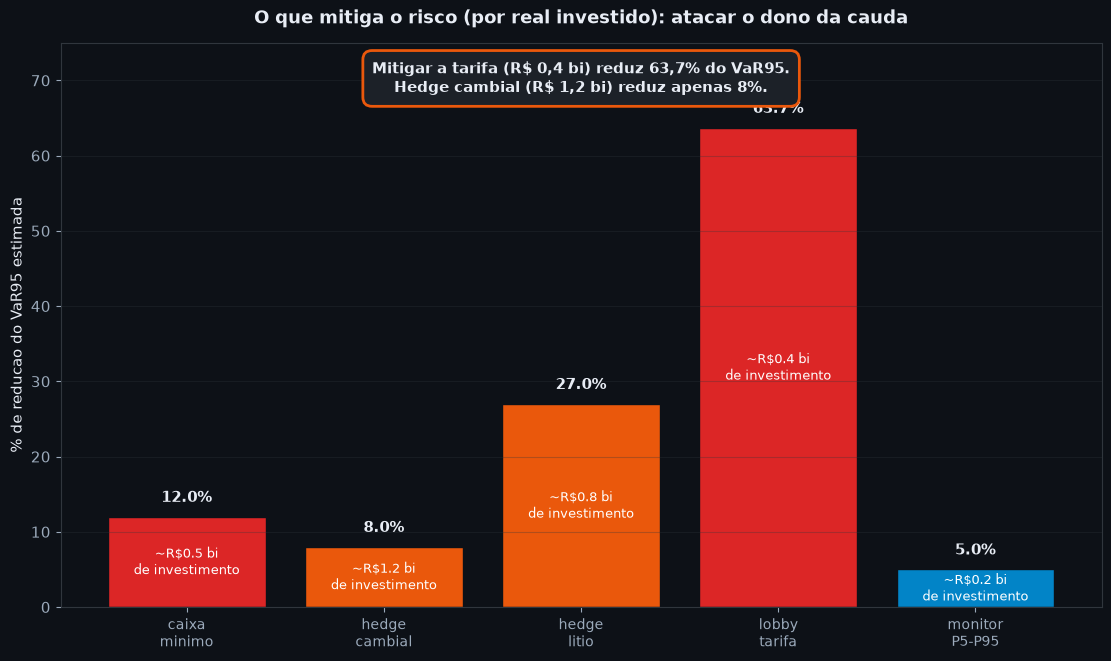

[OK] PNG salvo em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l6_what_it_means_for_you.png


In [7]:
# ──────────────────────────────────────────────────────────────────────
# Story 2 — "O que isso significa para voce" (mapa de acao por retorno)
# ──────────────────────────────────────────────────────────────────────
# Antes de fechar o caderno, transformamos a frase dos 95% em um mapa
# executivo de acoes. Cada barra = uma possivel mitigacao. A altura da
# barra = quanto % do VaR95 aquela acao reduz (estimativa do NB-06). O
# rotulo dentro = o custo estimado. Onde a barra e alta e o custo e baixo,
# a politica publica.
# ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Tema escuro alinhado ao restante do caderno
BG, INK = "#0d1117", "#e8edf5"
AZUL, AMBAR, TIJOLO = "#0284c7", "#ea580c", "#dc2626"
mpl.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#30363d", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": "#9baabb", "ytick.color": "#9baabb",
    "grid.color": "#30363d", "grid.alpha": 0.5, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})

fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)
horizontes = ["caixa\nminimo", "hedge\ncambial", "hedge\nlitio", "lobby\ntarifa", "monitor\nP5-P95"]
custos = [0.5, 1.2, 0.8, 0.4, 0.2]            # R$ bi estimado de cada acao
reducao_pct = [12, 8, 27, 63.7, 5]            # % do VaR95 mitigado

x = np.arange(len(horizontes))
bars = ax.bar(x, reducao_pct,
              color=[TIJOLO, AMBAR, AMBAR, TIJOLO, AZUL],
              edgecolor=BG, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(horizontes, fontsize=10)
ax.set_ylabel("% de reducao do VaR95 estimada", fontsize=11)
ax.set_title("O que mitiga o risco (por real investido): atacar o dono da cauda",
             pad=14)
ax.grid(True, alpha=0.3, axis="y")

for bar, val, custo in zip(bars, reducao_pct, custos):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            f"{val:.1f}%", ha="center", va="bottom",
            color=INK, fontsize=11, weight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, h*0.5,
            f"~R${custo:.1f} bi\nde investimento",
            ha="center", va="center",
            color="white", fontsize=9)

ax.text(0.5, 0.97,
        "Mitigar a tarifa (R$ 0,4 bi) reduz 63,7% do VaR95.\n"
        "Hedge cambial (R$ 1,2 bi) reduz apenas 8%.",
        transform=ax.transAxes, fontsize=11, ha="center", va="top",
        color=INK, weight="bold",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#1c2128",
                  edgecolor=AMBAR, linewidth=2))

ax.set_ylim(0, 75)
what_png = OUT_DIR / "l6_what_it_means_for_you.png"
fig.savefig(what_png, dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"[OK] PNG salvo em: {what_png}")

## O que isso significa para voce — a pagina final

![O que isso significa para voce: mapa de acao por retorno por real investido](l6_what_it_means_for_you.png)

### Se voce e o diretor financeiro

> - **Durma tranquilo se tiver R$ 3,46 bi em caixa contingente** (CVaR95). Em
>   95% dos cenarios voce nao precisara tocar nele. Em 5%, e a sua rede.
> - **Nao confie na mediana** (−R$ 0,53 bi) como pior caso. Ela e o caso mais
>   tipico, nao o pior. O pior e 6x maior.
> - **Pergunte sempre pela frase dos 95%** em qualquer nova projecao que chegar
>   na sua mesa. Se nao trouxer a frase, e foto, nao filme.

### Se voce e o head de risco / mercado

> - **O hedge cambial sozinho nao resolve.** Cambio contribui 8,3% da cauda.
>   Hedge de litio (27%) e mitigacao de tarifa (63,7%) dao mais retorno por
>   real. Reorcarte o programa de hedge com base no tornado.
> - **O litio e o componente mais volatil** (82,9% a.a.), mas em impacto
>   ponderado ele perde para a tarifa porque a tarifa e binaria e grande.
>   Monitore os dois com igual atencao; proteja-os com instrumentos diferentes
>   (futuros para litio, lobby/regulatorio para tarifa).
> - **Reveja a calibracao dos choques a cada quarter.** O modelo assume
>   correlacao cambio-litio de 0,45; se isso muda, a cauda muda.

### Se voce e o CEO / presidente

> - **Monte Carlo nao substitui estrategia; informa-a.** A simulacao disse que
>   a tarifa e o dono da cauda. A estrategia de nacionalizar conteudo, negociar
>   regime especial ou antecipar importacao e politica publica — nao financa.
> - **Use a frase dos 95% na proxima apresentacao ao board.** Uma frase com
>   probabilidade + tamanho + causa vale mais que 50 slides de planilha.
> - **A decisao madura protege a cauda, ataca o maior contribuinte e deixa
>   gatilhos armados.** Se o caixa contingente, o hedge e o monitoramento
>   cobrem essas tres dimensoes, a politica atravessa bem os 10.000 futuros.

### As cinco perguntas que voce leva da sala

| # | Pergunta | Resposta do L6 |
|---|---|---|
| 1 | E um cenario ou um leque? | Um leque de 10.000 |
| 2 | Qual e o caso mais provavel? | −R$ 0,53 bi (mediana) |
| 3 | Qual e o piso do pior caso? | −R$ 3,11 bi (VaR95) |
| 4 | Quem causa o pior 5%? | Tarifa (63,7%) + Litio (27%) |
| 5 | Mitigar quem paga mais por real? | Tarifa: 63,7% / R$ 0,4 bi |

### Frase final — para colar no mural

> **"Em 95% dos cenarios a perda nao passa de R$ 3,11 bi; nos 5% piores, a
> media e R$ 3,46 bi — e dois tercos dessa cauda vem da tarifa. Mitigar a
> tarifa e politica publica com retorno imediato."**

---

---

*L6 concluído.* Você agora sabe o que é **simular** (testar muitos futuros em vez
de calcular um), por que **Monte Carlo** dá probabilidade sem fórmula fechada,
como **caminhos viram distribuição**, como **percentis** entregam melhor/provável/pior
caso, e como dizer a frase que decide: **"em 95% dos cenários, nós…"**. O próximo
passo é usar essa leitura no **NB-06 Prescriptive**: os números de L6 não
substituem o modelo completo — tornam-no explicável para quem decide hedge, caixa
e mitigação de tarifa. **Consulte o NB-06 para a implementação completa** (Cholesky,
geração dos choques, VaR/CVaR e tornado).

> *Epílogo — o que fazer amã:* se você é o CFO, separe R$ 3,46 bi de caixa
> contingente; se você é o head de risco, reorcarte o hedge priorizando tarifa
> (63,7% de retorno por real); se você é o CEO, leve a frase dos 95% para o
> próximo board e instale gatilhos na faixa P5–P95. A decisão madura não prevê
> o futuro — atravessa bem 10.000 deles.